# Refactored Analysis for Market Edge Evaluation
This notebook evaluates market edge using a more realistic approach to calculate daily profit.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from Database.Timescale import utils

In [174]:
# Fetch trades data
trades = utils.get_trades_data('dey1', '2024-01-01', '2025-05-15')

Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database ti

In [175]:
# Resample trades data to 15-minute OHLC candles
ohlc_daily = trades['price'].resample('1B').ohlc()
ohlc_15min = trades['price'].resample('15T').ohlc()

In [ ]:

# Calculate the mean price of the first hour for each day
ohlc['hour'] = ohlc.index.hour
ohlc['day'] = ohlc.index.date
first_hour_mean = ohlc[ohlc['hour'] == 9].groupby('day')['close'].mean()

# Merge the first-hour mean price back into the OHLC data
ohlc['first_hour_mean'] = ohlc['day'].map(first_hour_mean)

In [95]:
# Calculate daily profit using the first-hour mean price
ohlc['daily_return'] = ohlc.eval('close - first_hour_mean')

### Weekly Analysis and Filtering

In [96]:
# Add additional columns for analysis
ohlc['dayow'] = ohlc.index.day_of_week
ohlc['week'] = ohlc.index.isocalendar().week

# Filter out incomplete weeks
valid_weeks = ohlc.groupby('week').filter(lambda x: len(x) >= 5)['week'].unique()
ohlc = ohlc[ohlc['week'].isin(valid_weeks)]

### Strategy Evaluation

In [97]:
# Example strategy: Identify weeks with consistent daily returns
ohlc['state'] = np.where(ohlc['daily_return'] > 0, 'up', 'down')

# Group by week and analyze patterns
grouped = ohlc.groupby('week')
selected_rows = []

for week, group in grouped:
    if group['state'].nunique() == 1:  # All days in the same direction
        selected_rows.append(group)

result = pd.concat(selected_rows) if selected_rows else pd.DataFrame()
result

,open,high,low,close,hour,day,first_hour_mean,daily_return,dayow,week,state
datetime,,,,,,,,,,,
2024-01-15 00:00:00,NaN,NaN,NaN,NaN,0,2024-01-15,NaN,NaN,0,3,down
2024-01-15 00:15:00,NaN,NaN,NaN,NaN,0,2024-01-15,NaN,NaN,0,3,down
2024-01-15 00:30:00,NaN,NaN,NaN,NaN,0,2024-01-15,NaN,NaN,0,3,down
2024-01-15 00:45:00,NaN,NaN,NaN,NaN,0,2024-01-15,NaN,NaN,0,3,down
2024-01-15 01:00:00,NaN,NaN,NaN,NaN,1,2024-01-15,NaN,NaN,0,3,down
...,...,...,...,...,...,...,...,...,...,...,...
2024-01-21 22:45:00,NaN,NaN,NaN,NaN,22,2024-01-21,NaN,NaN,6,3,down
2024-01-21 23:00:00,NaN,NaN,NaN,NaN,23,2024-01-21,NaN,NaN,6,3,down
2024-01-21 23:15:00,NaN,NaN,NaN,NaN,23,2024-01-21,NaN,NaN,6,3,down


### Correlation Analysis

### Workflow for Testing New Ideas
This section introduces a modular workflow to test new strategies for profitability.

In [98]:
def calculate_daily_return(ohlc):
    """Calculate daily return using the first-hour mean price."""
    ohlc['daily_return'] = ohlc.eval('close - first_hour_mean')
    return ohlc

def filter_complete_weeks(ohlc):
    """Filter out incomplete weeks."""
    valid_weeks = ohlc.groupby('week').filter(lambda x: len(x) >= 5)['week'].unique()
    return ohlc[ohlc['week'].isin(valid_weeks)]

def strategy_4days_same_state(ohlc):
    """Identify weeks where the first 4 days have the same state."""
    grouped = ohlc.groupby('week')
    selected_rows = []
    for week, group in grouped:
        if group.loc[group['dayow'] < 4, 'state'].nunique() == 1:
            selected_row = group[group['dayow'] == 4]
            selected_rows.append(selected_row)
    return pd.concat(selected_rows) if selected_rows else pd.DataFrame()

def evaluate_strategy(result):
    """Evaluate the profitability of a strategy."""
    result['state_encoded'] = result['state'].map({'up': 1, 'down': -1})
    correlation = result['daily_return'].corr(result['state_encoded'])
    return correlation

# Apply workflow
ohlc = calculate_daily_return(ohlc)
ohlc = filter_complete_weeks(ohlc)
result = strategy_4days_same_state(ohlc)
correlation = evaluate_strategy(result)
print("Correlation for 4 days same state strategy:", correlation)

Correlation for 4 days same state strategy: nan


In [78]:
ohlc

,open,high,low,close,hour,day,first_hour_mean,daily_return,dayow,week,state
datetime,,,,,,,,,,,
2024-01-02 09:00:00,78.01,79.17,78.01,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down
2024-01-02 09:15:00,78.25,78.44,78.25,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down
2024-01-02 09:30:00,78.50,78.75,78.50,78.75,9,2024-01-02,78.3125,0.4375,1,1,up
2024-01-02 09:45:00,78.25,78.25,77.79,78.00,9,2024-01-02,78.3125,-0.3125,1,1,down
2024-01-02 10:00:00,77.50,77.50,76.99,77.00,10,2024-01-02,78.3125,-1.3125,1,1,down
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 16:30:00,79.65,80.00,79.65,79.99,16,2024-12-30,79.4800,0.5100,0,1,up
2024-12-30 16:45:00,79.95,80.00,79.87,79.98,16,2024-12-30,79.4800,0.5000,0,1,up
2024-12-30 17:00:00,80.00,80.20,80.00,80.20,17,2024-12-30,79.4800,0.7200,0,1,up


### Adding a New Strategy
To test a new idea, define a new strategy function and integrate it into the workflow.

In [99]:
def strategy_return_day_4(ohlc):
    """Select rows where dayow == 4 and analyze returns."""
    return ohlc[ohlc['dayow'] == 4]

# Test the new strategy
result_day_4 = strategy_return_day_4(ohlc)
correlation_day_4 = evaluate_strategy(result_day_4)
print("Correlation for return of day == 4 strategy:", correlation_day_4)

Correlation for return of day == 4 strategy: 0.7445892667570801


/var/folders/5t/zn7m2n_95xj1yjfc5dyh8pk80000gn/T/ipykernel_14189/2744614329.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['state_encoded'] = result['state'].map({'up': 1, 'down': -1})


### Gap Trading Strategy
This strategy identifies gaps between the daily close and the next day's open, trades against the gap, and closes the position at the gap level or after a maximum of 5 days. 15-minute candles are used for calculating executable open prices and metrics.

In [ ]:
def strategy_trade_against_gap(ohlc_15min, ohlc_daily):
    """Trade against gaps between daily close and next day's open, using daily close vs. open prices."""
    # Map daily close and open prices to 15-minute candles
    ohlc_daily['next_open'] = ohlc_daily['open'].shift(-1)
    ohlc_daily['gap'] = ohlc_daily['next_open'] - ohlc_daily['close']

    # Filter rows with significant gaps
    gap_threshold = 0.01  # Example: 1% gap
    gap_trades = ohlc_daily[ohlc_daily['gap'].abs() > gap_threshold].copy()

    # Define trade direction (against the gap)
    gap_trades['direction'] = np.where(gap_trades['gap'] > 0, 'sell', 'buy')

    # Map the daily gap trades to 15-minute candles for execution
    def get_execution_open(date):
        try:
            return ohlc_15min.loc[ohlc_15min.index.date == date, 'open'].iloc[0]
        except IndexError:
            return np.nan  # Handle missing data gracefully

    gap_trades['execution_open'] = gap_trades.index.map(lambda date: get_execution_open(date))

    # Drop rows with missing execution prices
    gap_trades.dropna(subset=['execution_open'], inplace=True)

    # Return early if gap_trades is empty
    if gap_trades.empty:
        return gap_trades

    # Align ohlc_15min data with gap_trades
    ohlc_15min_aligned = ohlc_15min.loc[gap_trades.index]

    # Calculate target price (gap level)
    gap_trades['target_price'] = gap_trades['close']

    # Simulate trade execution and calculate metrics
    gap_trades['drawdown'] = np.where(
        gap_trades['direction'] == 'buy',
        ohlc_15min_aligned['low'] - gap_trades['execution_open'],
        gap_trades['execution_open'] - ohlc_15min_aligned['high']
    )

    # Calculate time to close position (max 5 days)
    gap_trades['time_to_close'] = (
        gap_trades.index.to_series().shift(-1) - gap_trades.index.to_series()
    ).dt.total_seconds() / 60  # Time in minutes

    # Cap the holding period to 5 days (5 * 24 * 60 minutes)
    max_holding_period = 5 * 24 * 60
    gap_trades['time_to_close'] = gap_trades['time_to_close'].clip(upper=max_holding_period)

    return gap_trades

In [107]:
strategy_trade_against_gap(ohlc, ohlc_daily)

,open,high,low,close,next_open,gap,direction,execution_open
datetime,,,,,,,,


In [ ]:
ohlc

,open,high,low,close,hour,day,first_hour_mean,daily_return,dayow,week,state
datetime,,,,,,,,,,,
2024-01-02 09:00:00,78.01,79.17,78.01,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down
2024-01-02 09:15:00,78.25,78.44,78.25,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down
2024-01-02 09:30:00,78.50,78.75,78.50,78.75,9,2024-01-02,78.3125,0.4375,1,1,up
2024-01-02 09:45:00,78.25,78.25,77.79,78.00,9,2024-01-02,78.3125,-0.3125,1,1,down
2024-01-02 10:00:00,77.50,77.50,76.99,77.00,10,2024-01-02,78.3125,-1.3125,1,1,down
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 16:30:00,79.65,80.00,79.65,79.99,16,2024-12-30,79.4800,0.5100,0,1,up
2024-12-30 16:45:00,79.95,80.00,79.87,79.98,16,2024-12-30,79.4800,0.5000,0,1,up
2024-12-30 17:00:00,80.00,80.20,80.00,80.20,17,2024-12-30,79.4800,0.7200,0,1,up


In [116]:
def calculate_return_against_close(ohlc_15min):
    """
    Calculate the return against the close of the 15-minute candles.

    Parameters:
        ohlc_15min (pd.DataFrame): DataFrame containing 15-minute OHLC data with a 'close' column.

    Returns:
        pd.DataFrame: Updated DataFrame with a new column 'return_against_close'.
    """
    ohlc_15min['return_against_close'] = ohlc_15min['close'].pct_change() * 100
    return ohlc_15min

# Apply the function to the 15-minute OHLC data
ohlc = calculate_return_against_close(ohlc)
ohlc

/var/folders/5t/zn7m2n_95xj1yjfc5dyh8pk80000gn/T/ipykernel_14189/2474713175.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ohlc_15min['return_against_close'] = ohlc_15min['close'].pct_change() * 100


,open,high,low,close,hour,day,first_hour_mean,daily_return,dayow,week,state,return_against_close
datetime,,,,,,,,,,,,
2024-01-02 09:00:00,78.01,79.17,78.01,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down,NaN
2024-01-02 09:15:00,78.25,78.44,78.25,78.25,9,2024-01-02,78.3125,-0.0625,1,1,down,0.000000
2024-01-02 09:30:00,78.50,78.75,78.50,78.75,9,2024-01-02,78.3125,0.4375,1,1,up,0.638978
2024-01-02 09:45:00,78.25,78.25,77.79,78.00,9,2024-01-02,78.3125,-0.3125,1,1,down,-0.952381
2024-01-02 10:00:00,77.50,77.50,76.99,77.00,10,2024-01-02,78.3125,-1.3125,1,1,down,-1.282051
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-30 16:30:00,79.65,80.00,79.65,79.99,16,2024-12-30,79.4800,0.5100,0,1,up,0.553111
2024-12-30 16:45:00,79.95,80.00,79.87,79.98,16,2024-12-30,79.4800,0.5000,0,1,up,-0.012502
2024-12-30 17:00:00,80.00,80.20,80.00,80.20,17,2024-12-30,79.4800,0.7200,0,1,up,0.275069


In [119]:
import pandas as pd
import numpy as np

def calculate_volatility_index(ohlc, num_bins=10, window=4):
    """
    Calculates a volatility index by normalizing return against a rolling mean of recent high-low ranges.

    Args:
        ohlc (pd.DataFrame): DataFrame containing 'return_against_close', 'low', and 'high' columns.
        num_bins (int): Number of bins to discretize the volatility index into.
        window (int): Number of previous entries to use for calculating the rolling mean of the low-high range.

    Returns:
        pd.DataFrame: DataFrame with an added 'return_VI' column representing the volatility index,
                      and 'VI_bin' column representing the discretized volatility index.
    """

    # Calculate the absolute difference between high and low
    ohlc['hl_range'] = (ohlc['low'] - ohlc['high']).abs()

    # Calculate the rolling mean of the high-low range
    ohlc['rolling_hl_mean'] = ohlc['hl_range'].rolling(window=window).mean().shift()  # shift is same as .shift(1)

    # Calculate the volatility index (return normalized by rolling volatility)
    ohlc['return_VI'] = ohlc['return_against_close'] / ohlc['rolling_hl_mean']

    # Discretize the volatility index into bins.  qcut bins based on quantiles
    ohlc['VI_bin'] = pd.qcut(ohlc['return_VI'], q=num_bins, labels=False)

    ohlc.dropna(inplace=True)

    return ohlc


In [121]:
# Assuming 'ohlc' DataFrame already exists with 'return_against_close', 'low', and 'high' columns
ohlc = calculate_volatility_index(ohlc.copy(), num_bins=10, window=4) # pass a copy to avoid modifying the original DataFrame

ohlc[['return_VI', 'VI_bin']]


,return_VI,VI_bin
datetime,,
2024-01-02 11:30:00,-1.244942,0.0
2024-01-02 11:45:00,-0.741359,1.0
2024-01-02 12:00:00,-0.233427,3.0
2024-01-02 12:15:00,-0.970128,1.0
2024-01-02 12:30:00,-0.554017,2.0
...,...,...
2024-12-30 16:30:00,6.507191,9.0
2024-12-30 16:45:00,-0.078135,4.0
2024-12-30 17:00:00,1.571822,8.0


In [ ]:
ohlc_daily.

,open,high,low,close,next_open,gap
datetime,,,,,,
2024-01-02,78.01,79.17,74.35,74.40,76.25,1.85
2024-01-03,76.25,78.30,75.00,78.00,78.98,0.98
2024-01-04,78.98,79.50,77.00,79.01,78.50,-0.51
2024-01-05,78.50,81.30,78.25,81.00,77.75,-3.25
2024-01-08,77.75,78.00,73.30,73.67,71.36,-2.31
...,...,...,...,...,...,...
2024-12-24,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-26,NaN,NaN,NaN,NaN,109.00,NaN


In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-state the VI function for consistency (same as previous solution)
def calculate_volatility_index(ohlc, num_bins=10, window=4):
    """
    Calculates a volatility index.
    Expects ohlc to have 'return_against_close', 'low', and 'high' columns.
    'low' and 'high' should be the intraday 15-min low/high for this calculation.
    """
    ohlc_calc = ohlc.copy()
    if not all(col in ohlc_calc.columns for col in ['low', 'high', 'return_against_close']):
        print("Error in calculate_volatility_index: Missing required columns (low, high, or return_against_close).")
        if 'low' not in ohlc_calc.columns: ohlc_calc['low'] = np.nan
        if 'high' not in ohlc_calc.columns: ohlc_calc['high'] = np.nan
        if 'return_against_close' not in ohlc_calc.columns: ohlc_calc['return_against_close'] = np.nan
    ohlc_calc['hl_range'] = (ohlc_calc['high'] - ohlc_calc['low']).abs() # Use intraday H/L
    ohlc_calc['rolling_hl_mean'] = ohlc_calc['hl_range'].rolling(window=window, min_periods=1).mean().shift(1) # min_periods=1 to get values sooner
    ohlc_calc['return_VI'] = ohlc_calc['return_against_close'] / ohlc_calc['rolling_hl_mean']
    # Replace inf/-inf with NaN if division by zero occurred in rolling_hl_mean
    ohlc_calc['return_VI'].replace([np.inf, -np.inf], np.nan, inplace=True)

    if ohlc_calc['return_VI'].isnull().all():
        ohlc_calc['VI_bin'] = np.nan
    else:
        try:
            series_to_bin = ohlc_calc['return_VI'].dropna()
            if len(series_to_bin) < num_bins : # Need enough unique points to form bins
                 ohlc_calc['VI_bin'] = np.nan
            elif series_to_bin.nunique() < 2: # If all values are the same after dropna
                 ohlc_calc['VI_bin'] = np.nan
            else:
                ohlc_calc['VI_bin'] = pd.qcut(series_to_bin, q=num_bins, labels=False, duplicates='drop')
                # Reindex VI_bin to match ohlc_calc if qcut dropped NaNs and changed index
                ohlc_calc['VI_bin'] = ohlc_calc['VI_bin'].reindex(ohlc_calc.index)

        except Exception as e:
            print(f"Error during pd.qcut: {e}. Setting VI_bin to NaN.")
            ohlc_calc['VI_bin'] = np.nan
    return ohlc_calc


# Modified strategy_trade_against_gap_with_vi to yield direction
def strategy_trade_against_gap_with_vi(ohlc_15min, ohlc_daily, thold, num_bins=7, vi_window=4):
    """
    1. Identifies gap trading opportunities.
    2. Calculates the position open price (mean price between 9-10 AM on Day D).
    3. Calculates a distribution of Volatility Index (VI) bin *counts* for Day D after 10 AM.
    4. **Also yields the 'direction' of the trade for each signal.**

    Yields:
        tuple: (trade_date, vi_distribution, direction)
               where trade_date is the signal date (D-1),
               vi_distribution is the list of bin counts (length num_bins),
               direction is 'long' or 'short'.
    """
    ohlc_daily_copy = ohlc_daily.copy()
    ohlc_15min_copy = ohlc_15min.copy()

    ohlc_daily_copy['next_open'] = ohlc_daily_copy['open'].shift(-1)
    ohlc_daily_copy['gap'] = ohlc_daily_copy['next_open'] - ohlc_daily_copy['close']
    gap_trades_signals = ohlc_daily_copy[ohlc_daily_copy['gap'].abs() > thold].copy()

    for signal_date_d_minus_1, trade_signal_row in gap_trades_signals.iterrows():
        day_d = signal_date_d_minus_1 + pd.Timedelta(days=1)

        # Determine direction (crucial to do this *before* skipping if exec price is bad)
        if trade_signal_row['gap'] > 0:
            direction = 'short'  # Gap up, sell
        else:
            direction = 'long'   # Gap down, buy


        # Calculate execution_open (mean of 9-10 AM on Day D)
        try:
            day_d_data_9_10 = ohlc_15min_copy[
                (ohlc_15min_copy.index.date == day_d.date()) &
                (ohlc_15min_copy.index.time >= pd.to_datetime('09:00:00').time()) &
                (ohlc_15min_copy.index.time < pd.to_datetime('10:00:00').time())
            ]
            if day_d_data_9_10.empty:
                yield signal_date_d_minus_1, [0] * num_bins, direction # Still yield empty results
                continue
            execution_open = day_d_data_9_10['open'].mean()
            if np.isnan(execution_open):
                 yield signal_date_d_minus_1, [0] * num_bins, direction # Still yield even if bad data
                 continue

        except Exception as e:
            yield signal_date_d_minus_1, [0] * num_bins, direction # Important: Handle errors

            continue

        # Get 15-min data for Day D from 10:00 AM onwards
        day_d_data_after_10am = ohlc_15min_copy[
            (ohlc_15min_copy.index.date == day_d.date()) &
            (ohlc_15min_copy.index.time >= pd.to_datetime('10:00:00').time())
        ]

        if day_d_data_after_10am.empty:
            yield signal_date_d_minus_1, [0] * num_bins, direction # Return an empty result

            continue

        data_for_vi_calc = day_d_data_after_10am.copy()
        close_d_minus_1 = trade_signal_row['close']
        if close_d_minus_1 == 0:
            yield signal_date_d_minus_1, [0] * num_bins, direction # still return if close is zero

            continue
        data_for_vi_calc['return_against_close'] = (execution_open - close_d_minus_1) / close_d_minus_1 # Close D-1 is our target reference


        # Calculate VI and now handle the binnage
        data_with_vi = calculate_volatility_index(data_for_vi_calc, num_bins=num_bins, window=vi_window)
        if 'VI_bin' in data_with_vi.columns and not data_with_vi['VI_bin'].isnull().all():
            # Get the Series of VI_bin values, drop NaNs that might exist from rolling window
            vi_bin_series = data_with_vi['VI_bin'].dropna()

            if not vi_bin_series.empty:
                # Count occurrences of each bin
                bin_counts = vi_bin_series.value_counts()
                # Create a list of length num_bins, initialized to 0
                # Then populate with counts. Bins are 0 to num_bins-1.
                distribution_list = [0] * num_bins
                for bin_label, count in bin_counts.items():
                    if 0 <= int(bin_label) < num_bins: # Ensure bin_label is valid
                        distribution_list[int(bin_label)] = count
                yield signal_date_d_minus_1, distribution_list, direction # Yield with the distribution
            else: # If all VI_bins were NaN
                yield signal_date_d_minus_1, [0] * num_bins, direction # Still yield what you know

        else:
            yield signal_date_d_minus_1, [0] * num_bins, direction # Still yield on other issues

# Plot functions
def plot_vi_bin_histograms_by_direction(vi_distributions, directions):
    """
    Plots two histograms of VI bin counts with bar opacity representing density,
    one for short and one for long positions.
    """

    short_distributions = []
    long_distributions = []

    for key, vi_dist in vi_distributions.items():
        if key in directions:
            if directions[key] == 'short':
                short_distributions.append(vi_dist)
            elif directions[key] == 'long':
                long_distributions.append(vi_dist)
            else:
                print(f"Warning: Invalid direction '{directions[key]}' for key '{key}'. Skipping.")
        else:
            print(f"Warning: No direction found for key '{key}'. Skipping.")

    # Convert lists to numpy arrays
    short_array = np.array(short_distributions) if short_distributions else np.array([])
    long_array = np.array(long_distributions) if long_distributions else np.array([])


    def plot_histogram(vi_array, title):
        if vi_array.size == 0:
            print(f"No data to plot for {title}.")
            return

        total_counts_per_bin = vi_array.sum(axis=0)
        max_count = total_counts_per_bin.max() if total_counts_per_bin.max() > 0 else 1
        density = total_counts_per_bin / max_count

        num_bins_plot = len(total_counts_per_bin)
        bins_x_axis = np.arange(num_bins_plot)

        plt.figure(figsize=(10, 6))
        for i, count in enumerate(total_counts_per_bin):
            plt.bar(i, count, color='blue', alpha=density[i])

        plt.xlabel('VI Bin')
        plt.ylabel('Total Count (Aggregated)')
        plt.title(title)
        plt.xticks(bins_x_axis)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

    plot_histogram(short_array, 'Aggregated Histogram of VI Bins for Short Positions')
    plot_histogram(long_array, 'Aggregated Histogram of VI Bins for Long Positions')


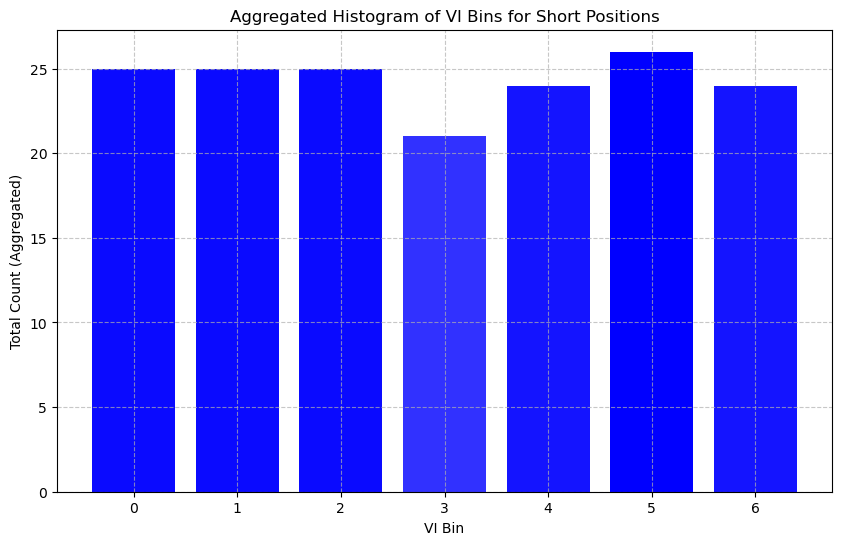

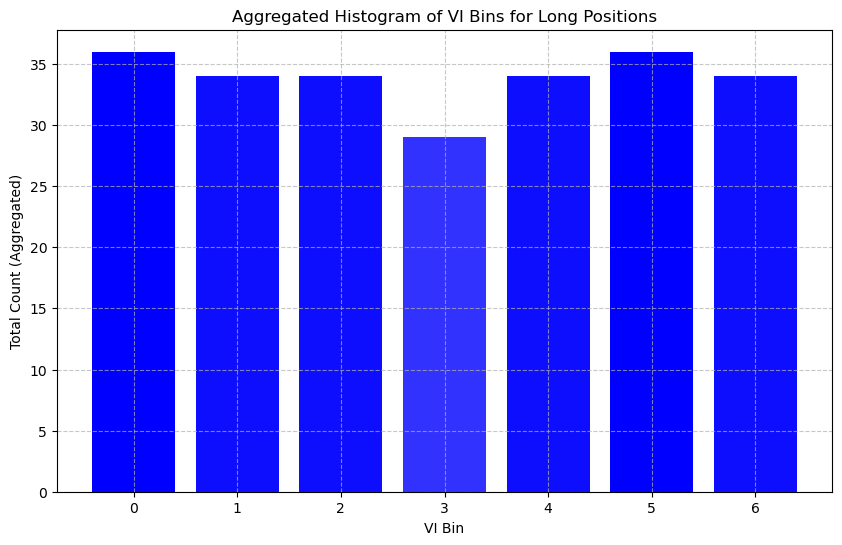

In [158]:
import warnings
warnings.filterwarnings('ignore')
# Resample trades data to 15-minute OHLC candles
ohlc_daily_df = trades['price'].resample('1B').ohlc()
ohlc_15min_df = trades['price'].resample('15T').ohlc()
# Example usage:
# Assuming 'ohlc_15min_df' and 'ohlc_daily_df' DataFrames exist

num_bins = 7 # As previously defined
thold = 2.0
my_all_vi_distributions = {}
my_directions = {} # Make sure to have it as a global variable

# Populate the dictionaries and direction using modified function
for signal_date, vi_distribution, direction in strategy_trade_against_gap_with_vi(ohlc_15min_df, ohlc_daily_df, thold, num_bins):
    my_all_vi_distributions[signal_date] = vi_distribution
    my_directions[signal_date] = direction

# Ensure the dictionaries are populated
if my_all_vi_distributions:
    plot_vi_bin_histograms_by_direction(my_all_vi_distributions, my_directions)
else:
    print("No VI distributions were generated. Check data and signal generation logic.")


In [159]:
import pandas as pd
import numpy as np

def strategy_symmetric_consecutive_closes_correlation(ohlc_df, n):
    """
    Finds correlation between the direction of a sequence of 'n' consecutive daily closes
    and whether the day after this sequence has a confirming or reversing close relative to its open.

    - After 'n' UP closes, checks if next day is CLOSE < OPEN (reversal down).
    - After 'n' DOWN closes, checks if next day is CLOSE > OPEN (reversal up).

    Parameters:
        ohlc_df (pd.DataFrame): DataFrame containing daily OHLC data with 'close' and 'open' columns.
                               It MUST have a DatetimeIndex.
        n (int): Number of consecutive days with closes in the same direction.

    Returns:
        float: Correlation between an indicator of sequence direction and an indicator of next day's outcome.
               Returns np.nan if not enough data or no valid sequences.
    """
    ohlc = ohlc_df.copy() # Work on a copy

    if not isinstance(ohlc.index, pd.DatetimeIndex):
        raise ValueError("Input DataFrame 'ohlc_df' must have a DatetimeIndex.")

    # 1. Determine daily direction (relative to previous close)
    ohlc['daily_change_direction'] = np.sign(ohlc['close'].diff()) # 1 for up, -1 for down, 0 for same (NaN for first)
    ohlc.dropna(subset=['daily_change_direction'], inplace=True) # Remove first row with NaN
    if ohlc.empty:
        return np.nan

    # 2. Identify consecutive sequences
    # A new sequence starts when the direction changes
    ohlc['sequence_group'] = (ohlc['daily_change_direction'] != ohlc['daily_change_direction'].shift()).cumsum()
    
    # 3. Calculate the length of each day within its sequence
    ohlc['sequence_day_number'] = ohlc.groupby('sequence_group').cumcount() + 1

    # 4. Find the end of sequences of exactly length 'n'
    # These are rows where sequence_day_number is 'n'
    # We also need to know the direction of this sequence.
    ends_of_n_sequences = ohlc[ohlc['sequence_day_number'] == n].copy()

    if ends_of_n_sequences.empty:
        print(f"No sequences of length {n} found.")
        return np.nan

    # 5. For each end_of_n_sequence, look at the NEXT day's open and close
    results = []
    for idx, row in ends_of_n_sequences.iterrows():
        next_day_idx = idx + pd.Timedelta(days=1)
        
        if next_day_idx in ohlc.index:
            next_day_data = ohlc.loc[next_day_idx]
            sequence_direction = row['daily_change_direction'] # Direction of the n-day sequence
            
            next_day_close = next_day_data['close']
            next_day_open = next_day_data['open']
            
            outcome_observed = np.nan
            # After N 'up' days (sequence_direction == 1), we expect/check for close < open
            if sequence_direction == 1: # Sequence was 'up'
                if next_day_close < next_day_open:
                    outcome_observed = 1 # Expected reversal happened (down day)
                else:
                    outcome_observed = 0 # No reversal / continued up / flat
            # After N 'down' days (sequence_direction == -1), we expect/check for close > open
            elif sequence_direction == -1: # Sequence was 'down'
                if next_day_close > next_day_open:
                    outcome_observed = 1 # Expected reversal happened (up day)
                else:
                    outcome_observed = 0 # No reversal / continued down / flat
            
            if not np.isnan(outcome_observed):
                results.append({
                    'sequence_end_date': idx,
                    'sequence_direction_encoded': sequence_direction, # 1 for up, -1 for down
                    'next_day_outcome_observed': outcome_observed    # 1 if expected reversal, 0 otherwise
                })
        # else: print(f"Next day {next_day_idx} not in OHLC data for sequence ending {idx}")


    if not results:
        print("No valid next-day outcomes found for sequences.")
        return np.nan

    analysis_df = pd.DataFrame(results)

    if len(analysis_df) < 2: # Need at least 2 points for correlation
        print("Not enough data points for correlation.")
        return np.nan
        
    # 6. Calculate Correlation
    # We are correlating the 'direction of the sequence' with 'whether the expected reversal occurred'.
    # For instance, does an "up sequence" (encoded as 1) tend to be followed by "reversal observed" (encoded as 1)?
    # Or does a "down sequence" (encoded as -1) tend to be followed by "reversal observed" (encoded as 1)?
    # A positive correlation would mean that up-sequences are more likely to have the expected down-reversal
    # AND down-sequences are more likely to have the expected up-reversal.
    # A negative correlation would mean the opposite (e.g. up-sequences are less likely to reverse down than down-sequences are to reverse up, or vice versa).
    
    # To make this more direct for "is there a general tendency to reverse after N days":
    # We can just correlate a constant (like sequence length, which is always 'n') with 'next_day_outcome_observed'.
    # Or, more simply, what's the average of 'next_day_outcome_observed'?
    
    # Let's stick to your original idea of correlation.
    # `sequence_direction_encoded` is 1 for up, -1 for down.
    # `next_day_outcome_observed` is 1 if the *specific expected reversal for that sequence direction* happened.

    correlation = analysis_df['sequence_direction_encoded'].corr(analysis_df['next_day_outcome_observed'])
    
    # For interpretation:
    # If corr is positive: "up" sequences tend to have their expected reversal (outcome=1),
    #                      OR "down" sequences tend NOT to have their expected reversal (outcome=0 if sequence_direction_encoded is -1).
    # This specific correlation might be tricky to interpret directly as "overall reversal tendency".
    
    # A simpler metric: What percentage of times did the expected reversal happen?
    overall_reversal_rate = analysis_df['next_day_outcome_observed'].mean()
    print(f"Overall rate of expected reversals after {n} days: {overall_reversal_rate:.2%}")

    # Rate for up sequences reversing down
    up_sequences = analysis_df[analysis_df['sequence_direction_encoded'] == 1]
    if not up_sequences.empty:
        up_reversal_rate = up_sequences['next_day_outcome_observed'].mean()
        print(f"Rate of UP sequences reversing DOWN: {up_reversal_rate:.2%} (out of {len(up_sequences)} up sequences)")

    # Rate for down sequences reversing up
    down_sequences = analysis_df[analysis_df['sequence_direction_encoded'] == -1]
    if not down_sequences.empty:
        down_reversal_rate = down_sequences['next_day_outcome_observed'].mean()
        print(f"Rate of DOWN sequences reversing UP: {down_reversal_rate:.2%} (out of {len(down_sequences)} down sequences)")

    return correlation


### Correlations UP/DOWN

In [215]:
strategy_symmetric_consecutive_closes_correlation(ohlc_daily, 3)

Overall rate of expected reversals after 3 days: 53.85%
Rate of UP sequences reversing DOWN: 28.57% (out of 14 up sequences)
Rate of DOWN sequences reversing UP: 83.33% (out of 12 down sequences)


-0.5476190476190474

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # For plotting if needed

def backtest_consecutive_closes_reversal_absolute_tp_sl(
    ohlc_15min, ohlc_daily, n_consecutive_days,
    take_profit_abs_points=0.8,
    stop_loss_abs_points=1.0
):
    """
    Backtests a strategy that trades reversals after 'n_consecutive_days'
    of closes in the same direction, using ABSOLUTE take profit and stop loss points.
    Tracks P&L in absolute price points. Robust EOD exit.
    """
    ohlc_daily_copy = ohlc_daily.copy()
    ohlc_15min_copy = ohlc_15min.copy()

    if not isinstance(ohlc_daily_copy.index, pd.DatetimeIndex) or \
       not isinstance(ohlc_15min_copy.index, pd.DatetimeIndex):
        raise ValueError("Input DataFrames 'ohlc_daily' and 'ohlc_15min' must have a DatetimeIndex.")

    # --- 1. Identify Consecutive Close Sequences on Daily Data ---
    ohlc_daily_copy['daily_change_direction'] = np.sign(ohlc_daily_copy['close'].diff())
    ohlc_daily_copy.dropna(subset=['daily_change_direction'], inplace=True)
    if ohlc_daily_copy.empty:
        return pd.DataFrame()

    ohlc_daily_copy['sequence_group'] = (ohlc_daily_copy['daily_change_direction'] != ohlc_daily_copy['daily_change_direction'].shift()).cumsum()
    ohlc_daily_copy['sequence_day_number'] = ohlc_daily_copy.groupby('sequence_group').cumcount() + 1
    signal_days_df = ohlc_daily_copy[ohlc_daily_copy['sequence_day_number'] == n_consecutive_days].copy()

    if signal_days_df.empty:
        return pd.DataFrame()

    trades_log = []

    # --- 2. Iterate Through Each Signal ---
    for signal_end_date_d_minus_1, signal_row in signal_days_df.iterrows():
        trade_execution_day = signal_end_date_d_minus_1 + pd.Timedelta(days=1)

        min_time_needed_for_entry = pd.to_datetime('10:00:00').time() # Need data up to this time for entry calc
        if not ohlc_15min_copy[(ohlc_15min_copy.index.date == trade_execution_day.date()) & (ohlc_15min_copy.index.time < min_time_needed_for_entry)].empty:
            pass
        else:
            # print(f"Skipping signal from {signal_end_date_d_minus_1.date()}: Not enough 15-min data for {trade_execution_day.date()} to calculate entry.")
            continue

        # --- 3. Determine Entry Price ---
        try:
            bars_9_to_10_am = ohlc_15min_copy[
                (ohlc_15min_copy.index.date == trade_execution_day.date()) &
                (ohlc_15min_copy.index.time >= pd.to_datetime('09:00:00').time()) &
                (ohlc_15min_copy.index.time < pd.to_datetime('10:00:00').time())
            ]
            if bars_9_to_10_am.empty: continue
            entry_price = bars_9_to_10_am['open'].mean()
            if pd.isna(entry_price): continue
        except Exception: continue

        # --- 4. Determine Trade Direction ---
        sequence_direction_type = signal_row['daily_change_direction']
        if sequence_direction_type == 1.0: direction = 'short'
        elif sequence_direction_type == -1.0: direction = 'long'
        else: continue

        # --- 5. Define TP and SL Prices (ABSOLUTE POINTS) ---
        if direction == 'long':
            tp_price = entry_price + take_profit_abs_points
            sl_price = entry_price - stop_loss_abs_points
        else: # short
            tp_price = entry_price - take_profit_abs_points
            sl_price = entry_price + stop_loss_abs_points

        # --- 6. Get Intraday Data for Monitoring ---
        intraday_bars_for_monitoring = ohlc_15min_copy[
            (ohlc_15min_copy.index.date == trade_execution_day.date()) &
            (ohlc_15min_copy.index.time >= pd.to_datetime('10:00:00').time()) # Monitoring starts from 10 AM
        ]
        if intraday_bars_for_monitoring.empty:
            # This means an entry was calculated (9-10am data existed), but no data after 10am for monitoring.
            # We could exit at entry (0 P&L) or skip. For now, let's log it as EOD at entry.
            # print(f"Warning: Entry for {trade_execution_day.date()} at {entry_price}, but no monitoring bars after 10 AM. Exiting at entry price (0 P&L).")
            exit_price = entry_price
            exit_reason = 'eod_no_monitoring_bars'
            exit_time = trade_execution_day + pd.Timedelta(hours=10) # Approx. time of decision
            pnl_abs_points = 0.0
            trades_log.append({
                'signal_end_date_D-1': signal_end_date_d_minus_1, 'trade_exec_date_D': trade_execution_day,
                'sequence_type_numeric': sequence_direction_type, 'direction_taken': direction,
                'entry_price_9_10_mean': entry_price, 'tp_price_level_abs': tp_price,
                'sl_price_level_abs': sl_price, 'exit_time': exit_time, 'exit_price': exit_price,
                'exit_reason': exit_reason, 'pnl_abs_points': pnl_abs_points
            })
            continue # Move to next signal


        exit_price = None
        exit_reason = None
        exit_time = None
        position_open_at_eod = True

        # --- 7. Iterate Through Intraday Bars ---
        for bar_time, bar_data in intraday_bars_for_monitoring.iterrows():
            if direction == 'long':
                if bar_data['high'] >= tp_price:
                    exit_price, exit_reason, exit_time, position_open_at_eod = tp_price, 'take_profit', bar_time, False
                    break
                elif bar_data['low'] <= sl_price:
                    exit_price, exit_reason, exit_time, position_open_at_eod = sl_price, 'stop_loss', bar_time, False
                    break
            else: # short
                if bar_data['low'] <= tp_price:
                    exit_price, exit_reason, exit_time, position_open_at_eod = tp_price, 'take_profit', bar_time, False
                    break
                elif bar_data['high'] >= sl_price:
                    exit_price, exit_reason, exit_time, position_open_at_eod = sl_price, 'stop_loss', bar_time, False
                    break
        
        # --- 8. Handle End-of-Day Exit (ROBUSTLY) ---
        if position_open_at_eod:
            # intraday_bars_for_monitoring is guaranteed not to be empty if we passed step 6's check
            last_bar_of_monitoring = intraday_bars_for_monitoring.iloc[-1]
            
            if pd.notna(last_bar_of_monitoring['close']):
                exit_price = last_bar_of_monitoring['close']
                exit_time = last_bar_of_monitoring.name # This is the timestamp of the last bar
                exit_reason = 'end_of_day'
            else:
                # Last bar's close is NaN. Try to find the most recent valid close price from that day's monitoring period.
                valid_closes_today = intraday_bars_for_monitoring['close'].dropna()
                if not valid_closes_today.empty:
                    exit_price = valid_closes_today.iloc[-1]
                    exit_time = valid_closes_today.index[-1] # Timestamp of that valid close
                    exit_reason = 'end_of_day_prev_valid_close'
                    # print(f"Note: EOD exit for {trade_execution_day.date()}, last bar close NaN. Used previous valid close: {exit_price} at {exit_time}")
                else:
                    # This is highly unlikely: all monitoring bars had NaN close.
                    # If this happens, we might assume exit at entry (0 P&L) or skip logging.
                    # print(f"Critical: EOD for {trade_execution_day.date()}, but ALL monitoring bars had NaN close. Exiting at entry (0 P&L).")
                    exit_price = entry_price
                    exit_time = intraday_bars_for_monitoring.index[-1] # Time of the last (NaN) bar
                    exit_reason = 'eod_all_monitor_nan_close'


        # --- 9. Calculate P&L (ABSOLUTE POINTS) and Log Trade ---
        if exit_price is not None: # Should always be true if we reached here due to robust EOD
            pnl_abs_points = 0.0
            if direction == 'long':
                pnl_abs_points = exit_price - entry_price
            else: # short
                pnl_abs_points = entry_price - exit_price
            
            trades_log.append({
                'signal_end_date_D-1': signal_end_date_d_minus_1,
                'trade_exec_date_D': trade_execution_day,
                'sequence_type_numeric': sequence_direction_type,
                'direction_taken': direction,
                'entry_price_9_10_mean': entry_price,
                'tp_price_level_abs': tp_price,
                'sl_price_level_abs': sl_price,
                'exit_time': exit_time, # This will now be correctly populated
                'exit_price': exit_price,
                'exit_reason': exit_reason,
                'pnl_abs_points': pnl_abs_points
            })
        # else: # This 'else' should ideally not be reached if EOD exit is robust
            # print(f"Warning: No valid exit price determined for trade on {trade_execution_day.date()}. Trade not logged.")


    return pd.DataFrame(trades_log)



--- Consecutive Closes Reversal Backtest (Absolute P&L, N=2) ---
Total Trades: 45
Average P&L per Trade (points): 0.2392
Win Rate (Take Profit): 31.11%
Win Rate (Positive P&L): 40.00%
Stop Loss Rate: 60.00%
End of Day Exits: 0.00%

Stats for SHORT trades (after UP sequence):
  Total Short Trades: 23
  Avg P&L (Short, points): 0.2098

Stats for LONG trades (after DOWN sequence):
  Total Long Trades: 22
  Avg P&L (Long, points): 0.2700

Sample Trades (Absolute P&L):
  signal_end_date_D-1 trade_exec_date_D direction_taken  \
0          2024-01-04        2024-01-05           short   
1          2024-01-09        2024-01-10            long   
2          2024-01-30        2024-01-31           short   
3          2024-02-08        2024-02-09            long   
4          2024-02-19        2024-02-20            long   

   entry_price_9_10_mean  exit_price                  exit_reason  \
0                78.6750     79.1750                    stop_loss   
1                72.5875     72.0875 

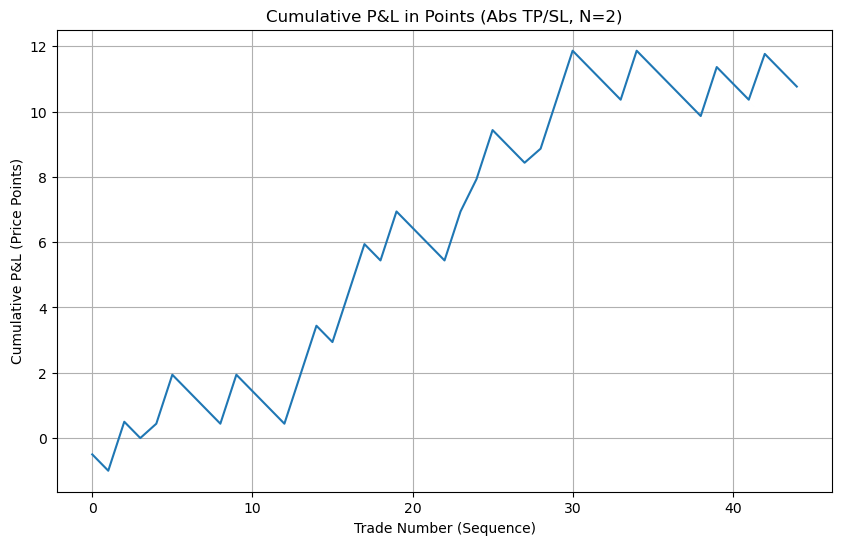

In [228]:
# --- Prepare your data (ensure DatetimeIndex and required columns) ---
# ohlc_daily_df = ...
# ohlc_15min_df = ... (same dummy data setup as before can be used for testing)

# --- Define Parameters with ABSOLUTE POINTS ---
n_days_sequence = 2
tp_absolute_points = 1.5
sl_absolute_points = 0.5

# --- Run the Backtest ---
trades_df_abs_pnl = backtest_consecutive_closes_reversal_absolute_tp_sl(
    ohlc_15min=ohlc_15min_df,
    ohlc_daily=ohlc_daily_df,
    n_consecutive_days=n_days_sequence,
    take_profit_abs_points=tp_absolute_points,
    stop_loss_abs_points=sl_absolute_points
)

# --- Analyze Results (with Absolute P&L) ---
if not trades_df_abs_pnl.empty:
    print(f"\n--- Consecutive Closes Reversal Backtest (Absolute P&L, N={n_days_sequence}) ---")
    print(f"Total Trades: {len(trades_df_abs_pnl)}")
    if len(trades_df_abs_pnl) > 0:
        # Average P&L in points
        print(f"Average P&L per Trade (points): {trades_df_abs_pnl['pnl_abs_points'].mean():.4f}")
        
        # Win Rate (still relevant based on TP/SL reasons or positive P&L)
        print(f"Win Rate (Take Profit): {len(trades_df_abs_pnl[trades_df_abs_pnl['exit_reason'] == 'take_profit']) / len(trades_df_abs_pnl):.2%}")
        print(f"Win Rate (Positive P&L): {len(trades_df_abs_pnl[trades_df_abs_pnl['pnl_abs_points'] > 0]) / len(trades_df_abs_pnl):.2%}")
        
        print(f"Stop Loss Rate: {len(trades_df_abs_pnl[trades_df_abs_pnl['exit_reason'] == 'stop_loss']) / len(trades_df_abs_pnl):.2%}")
        print(f"End of Day Exits: {len(trades_df_abs_pnl[trades_df_abs_pnl['exit_reason'] == 'end_of_day']) / len(trades_df_abs_pnl):.2%}")
        
        # Separate analysis for 'UP' sequence trades (which went SHORT)
        short_trades = trades_df_abs_pnl[trades_df_abs_pnl['direction_taken'] == 'short']
        if not short_trades.empty:
            print(f"\nStats for SHORT trades (after UP sequence):")
            print(f"  Total Short Trades: {len(short_trades)}")
            print(f"  Avg P&L (Short, points): {short_trades['pnl_abs_points'].mean():.4f}")

        # Separate analysis for 'DOWN' sequence trades (which went LONG)
        long_trades = trades_df_abs_pnl[trades_df_abs_pnl['direction_taken'] == 'long']
        if not long_trades.empty:
            print(f"\nStats for LONG trades (after DOWN sequence):")
            print(f"  Total Long Trades: {len(long_trades)}")
            print(f"  Avg P&L (Long, points): {long_trades['pnl_abs_points'].mean():.4f}")

        # --- Cumulative P&L (Sum of Absolute P&L Points) ---
        trades_df_abs_pnl['cumulative_pnl_abs_points'] = trades_df_abs_pnl['pnl_abs_points'].cumsum()
        
        print("\nSample Trades (Absolute P&L):")
        print(trades_df_abs_pnl[['signal_end_date_D-1', 
                                   'trade_exec_date_D', 
                                   'direction_taken', 
                                   'entry_price_9_10_mean', 
                                   'exit_price', 
                                   'exit_reason', 
                                   'pnl_abs_points', # Changed from return_pct
                                   'cumulative_pnl_abs_points']].head()) # Changed column

        # --- Plot Cumulative Absolute P&L ---
        trades_df_abs_pnl['cumulative_pnl_abs_points'].plot(
            title=f'Cumulative P&L in Points (Abs TP/SL, N={n_days_sequence})', 
            figsize=(10,6)
        )
        plt.ylabel("Cumulative P&L (Price Points)")
        plt.xlabel("Trade Number (Sequence)")
        plt.grid(True)
        plt.show()
        
else:
    print(f"No trades were executed for the consecutive {n_days_sequence}-day reversal strategy with absolute TP/SL.")



<Axes: >

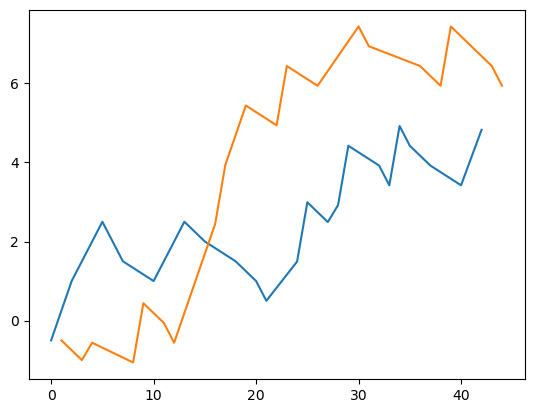

In [229]:
trades_df_abs_pnl[trades_df_abs_pnl['direction_taken'] == 'short']['pnl_abs_points'].cumsum().plot()
trades_df_abs_pnl[trades_df_abs_pnl['direction_taken'] == 'long']['pnl_abs_points'].cumsum().plot()

<Axes: >

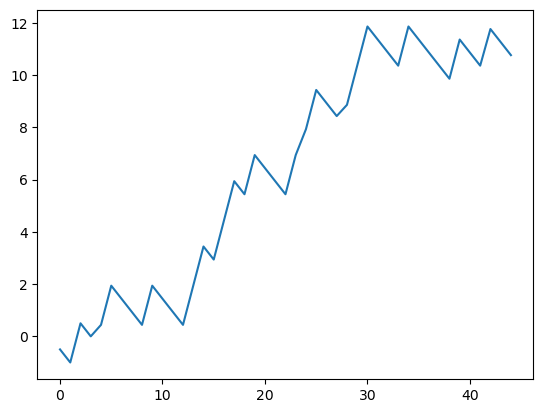

In [230]:
trades_df_abs_pnl['pnl_abs_points'].cumsum().plot()

In [231]:
ohlc_daily_df

,open,high,low,close
datetime,,,,
2024-01-02,78.01,79.17,74.35,74.40
2024-01-03,76.25,78.30,75.00,78.00
2024-01-04,78.98,79.50,77.00,79.01
2024-01-05,78.50,81.30,78.25,81.00
2024-01-08,77.75,78.00,73.30,73.67
...,...,...,...,...
2024-12-24,NaN,NaN,NaN,NaN
2024-12-25,NaN,NaN,NaN,NaN
2024-12-26,NaN,NaN,NaN,NaN
